
=== 2025-12-22 冬至日 J值汇总（l=3m, θ=45°）===

EAST墙面：
  J值：均值=0.13558 | 最大值=0.19058 | 最小值=0.072101
  遮阳率：均值=56.9% | 范围=49.4%~72.7%
  温度：均值=26.74℃ | 范围=24.99℃~28.26℃

SOUTH墙面：
  J值：均值=0.162029 | 最大值=0.244928 | 最小值=0.074638
  遮阳率：均值=66.4% | 范围=39.9%~100.0%
  温度：均值=26.55℃ | 范围=24.64℃~28.51℃

WEST墙面：
  J值：均值=0.153116 | 最大值=0.217754 | 最小值=0.072101
  遮阳率：均值=35.5% | 范围=0.0%~72.7%
  温度：均值=27.23℃ | 范围=24.99℃~29.01℃


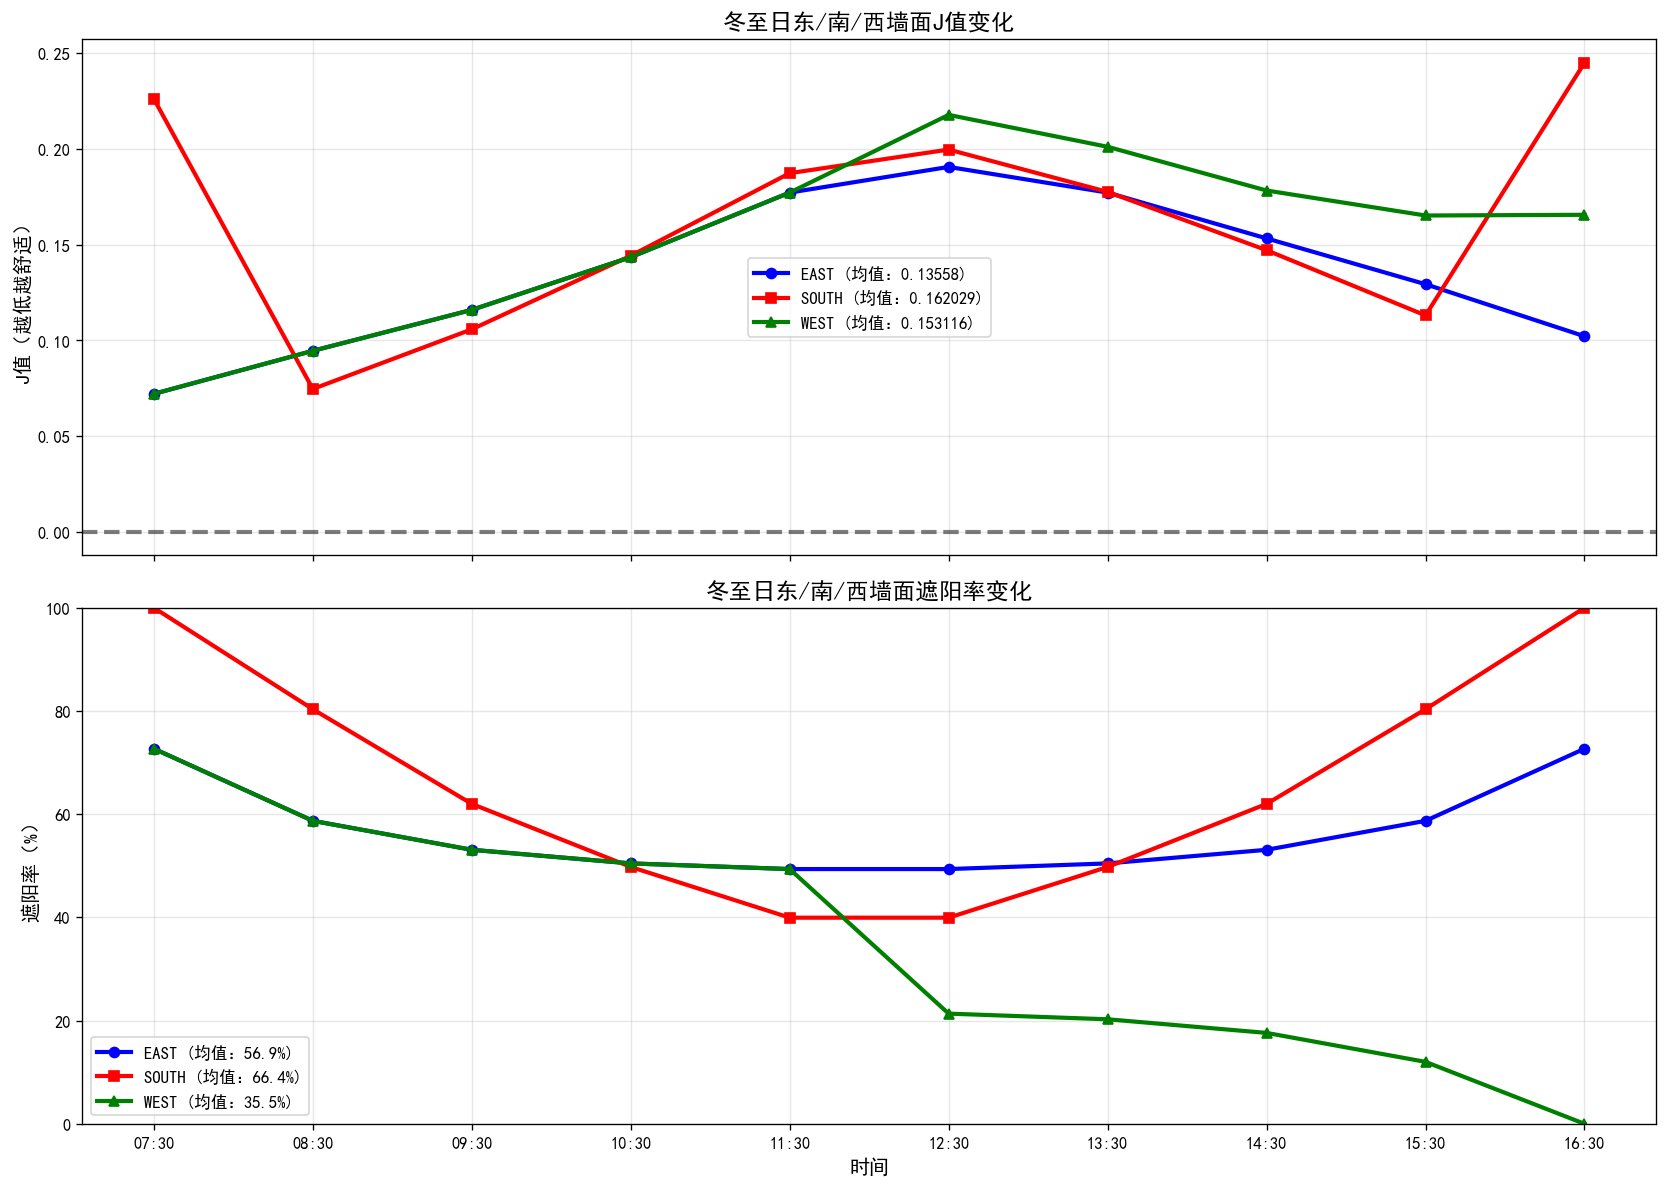

In [162]:
import math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

# ===================== 仅添加这部分字体配置，修复中文显示 =====================
plt.rcParams['font.sans-serif'] = ['SimHei']    # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False      # 正常显示负号
# =============================================================================

class SunIlluminanceCalculator:
    def __init__(self, lat: float, lng: float):
        self.lat = lat  # 纬度（北纬为正）
        self.lng = lng  # 经度（东经为正）
        self.PI = math.pi
        self.RAD = self.PI / 180.0
        self.I_sc = 1367.0
        self.EARTH_OBLIQUITY = 23.4397 * self.RAD  # 黄赤交角
        self.J1970 = 2440588.0
        self.J2000 = 2451545.0
        self.DAY_MS = 1000 * 60 * 60 * 24
        
        # 初始化温度数据（有日照/无日照，单位：℃）
        self._init_temperature_data()

    def _init_temperature_data(self):
        # 有日照时的温度（24小时）
        data_sun = np.array([
            296.0163007, 296.7024689, 296.9093501, 297.0639341, 297.5276481, 298.0179310,
            298.2261999, 298.9085913, 300.1002298, 300.8662137, 301.4847586, 302.3411005,
            302.5742203, 301.9964721, 301.2625588, 300.8178949, 300.5747770, 299.5839113,
            298.1380237, 297.3855772, 297.1427833, 296.9549780, 296.6360040, 296.0270487
        ])
        self.data_sun_celsius = data_sun - 273.0  # 转℃
        
        # 无日照时的温度（24小时）
        data_no_sun = np.array([
            24.1359699, 24.3986172, 24.5169152, 24.5502761, 24.5581122, 24.5980846,
            24.6597814, 24.6444436, 24.5570502, 24.7283847, 25.4604961, 26.3978844,
            26.9093899, 26.8007342, 26.3158262, 25.6997821, 25.1578972, 24.8514932,
            24.7331920, 24.6886416, 24.6522631, 24.5960635, 24.4930170, 24.3160976
        ])
        self.data_no_sun_celsius = data_no_sun

    # 补充遗漏的_to_julian方法（核心修复）
    def _to_julian(self, dt):
        """将datetime转换为儒略日"""
        # 基础儒略日计算（简化版，适用于1970年后）
        epoch = datetime(1970, 1, 1)
        delta = dt - epoch
        julian = self.J1970 + delta.total_seconds() / 86400.0
        return julian

    # 计算太阳位置（方位角/高度角）
    def calculate_sun_position(self, date_time):
        # 转换为儒略日
        dt = date_time
        julian = self._to_julian(dt)
        days = julian - self.J2000
        
        # 太阳黄经计算
        mean_longitude = (280.46646 + days * 0.98560028) % 360
        mean_anomaly = (357.52911 + days * 0.98560028) % 360
        ecliptic_longitude = mean_longitude + 1.914602 * math.sin(self.RAD * mean_anomaly)
        ecliptic_longitude_rad = self.RAD * ecliptic_longitude
        
        # 太阳赤纬
        declination = math.asin(math.sin(self.EARTH_OBLIQUITY) * math.sin(ecliptic_longitude_rad))
        
        # 时角计算
        local_time = dt.hour + dt.minute/60 + dt.second/3600
        hour_angle = (local_time - 12) * 15  # 每小时15度
        hour_angle_rad = self.RAD * hour_angle
        
        # 太阳高度角
        lat_rad = self.RAD * self.lat
        sin_altitude = (math.sin(lat_rad) * math.sin(declination) + 
                        math.cos(lat_rad) * math.cos(declination) * math.cos(hour_angle_rad))
        altitude = math.asin(max(min(sin_altitude, 1.0), -1.0))  # 限制在[-90°,90°]
        
        # 太阳方位角（从正南向西为正）
        cos_azimuth = (math.sin(declination) - math.sin(lat_rad) * math.sin(altitude)) / (
            math.cos(lat_rad) * math.cos(altitude)
        )
        cos_azimuth = max(min(cos_azimuth, 1.0), -1.0)  # 限制在[-1,1]
        azimuth = math.acos(cos_azimuth)
        
        # 修正方位角方向（上午为负，下午为正）
        if hour_angle > 0:
            azimuth = 2 * self.PI - azimuth
        
        return {
            'azimuth_deg': math.degrees(azimuth),  # 方位角（°）
            'altitude_deg': math.degrees(altitude)  # 高度角（°）
        }

    # 计算墙面光照系数（太阳入射与墙面外法线的重合度）
    def calculate_wall_light_coef(self, date_time, wall):
        sun_pos = self.calculate_sun_position(date_time)
        sun_azimuth = sun_pos['azimuth_deg']  # 太阳方位角（正南为0°，向西为正）
        sun_altitude = sun_pos['altitude_deg']
        
        # 墙面外法线的方位角（关键：明确墙面朝向的外法线）
        wall_normal_azimuth = {
            'east': 90,    # 东墙外法线朝东（正南+90°）
            'south': 0,    # 南墙外法线朝南（正南）
            'west': -90,   # 西墙外法线朝西（正南-90°）
            'north': 180   # 北墙外法线朝北（正南+180°）
        }[wall]
        
        # 计算太阳入射与墙面外法线的夹角φ（°）
        # 步骤1：水平面上的夹角
        horizontal_angle = abs(sun_azimuth - wall_normal_azimuth)
        horizontal_angle = min(horizontal_angle, 360 - horizontal_angle)  # 取最小夹角
        
        # 步骤2：三维空间的夹角φ（太阳入射与墙面外法线）
        phi_rad = math.atan2(
            math.sin(self.RAD * horizontal_angle) * math.cos(self.RAD * sun_altitude),
            math.sin(self.RAD * sun_altitude)
        )
        phi_deg = math.degrees(phi_rad)
        
        # 墙面光照系数k = cos(φ)（φ越小，k越大，光照越强）
        k = math.cos(self.RAD * phi_deg) if sun_altitude > 0 else 0.0
        k = max(k, 0.0)  # 排除负光照（太阳在墙面背面）
        
        return {
            'k': k,                # 墙面光照系数（0~1）
            'phi_deg': phi_deg,    # 太阳与墙面外法线夹角φ（°）
            'sun_azimuth': sun_azimuth,
            'sun_altitude': sun_altitude
        }

    # 计算遮阳系数（核心：物理意义准确）
    def calculate_shading_params(self, date_time, wall, H=6.0, l=1.0, theta_deg=30.0):
        """
        计算遮阳板的核心参数：
        - H：窗户高度（m）
        - l：遮阳板伸出长度（m）
        - theta_deg：遮阳板与建筑墙面的夹角θ（°）
        返回：遮阳率（0~1，1=100%遮挡）、φ、term
        """
        wall_coef = self.calculate_wall_light_coef(date_time, wall)
        k = wall_coef['k']
        phi_deg = wall_coef['phi_deg']
        
        # 除0保护（避免k=0时计算出错）
        k_safe = max(k, 1e-6)
        
        # 1. 计算term（物理意义：遮阳板有效遮挡长度/窗户高度）
        theta_rad = self.RAD * theta_deg
        phi_rad = self.RAD * phi_deg
        numerator = l * math.cos(phi_rad - theta_rad)  # 分子：遮阳板有效遮挡长度
        term = numerator / k_safe                      # term无截断，保留真实值
        
        # 2. 计算遮阳率（物理意义：0=无遮挡，1=100%遮挡）
        # 逻辑：term/H 代表遮挡比例，超过1则100%遮挡，低于0则无遮挡
        shading_ratio = term / H
        shading_ratio = max(min(shading_ratio, 1.0), 0.0)  # 限制在0~1之间
        
        return {
            'shading_ratio': shading_ratio,  # 遮阳率（0~1）
            'phi_deg': phi_deg,              # 太阳与墙面外法线夹角φ（°）
            'theta_deg': theta_deg,          # 遮阳板与墙面夹角θ（°）
            'term': term,                    # 中间值term
            'k': k                           # 墙面光照系数
        }

    # 计算墙面温度（结合遮阳率）
    def calculate_wall_temperature(self, date_time, wall, shading_ratio):
        hour = date_time.hour
        hour = max(0, min(23, hour))  # 限制小时在0~23
        
        # 有日照/无日照温度
        t_sun = self.data_sun_celsius[hour]
        t_no_sun = self.data_no_sun_celsius[hour]
        
        # 遮阳率越高，温度越接近无日照温度
        t_wall = t_sun * (1 - shading_ratio) + t_no_sun * shading_ratio
        return round(t_wall, 2)

    # 计算室内照度（结合遮阳率）
    def calculate_indoor_illuminance(self, date_time, wall, shading_ratio):
        wall_coef = self.calculate_wall_light_coef(date_time, wall)
        sun_altitude = wall_coef['sun_altitude']
        
        # 基础照度（无遮挡时）
        if sun_altitude <= 0:
            base_illuminance = 0.0
        else:
            DNI = 1000 * math.sin(self.RAD * sun_altitude)  # 直射辐照度
            base_illuminance = DNI * wall_coef['k'] * 100000  # 转换为照度
        
        # 遮阳后照度
        indoor_illuminance = base_illuminance * (1 - shading_ratio)
        return max(indoor_illuminance, 0.0)

    # 计算J值（按你的业务逻辑，无矛盾）
    def calculate_J(self, date_time, wall, H=6.0, l=1.0, theta_deg=30.0):
        # 1. 计算遮阳参数
        shading_params = self.calculate_shading_params(date_time, wall, H, l, theta_deg)
        shading_ratio = shading_params['shading_ratio']
        
        # 2. 计算室内照度和墙面温度
        indoor_ill = self.calculate_indoor_illuminance(date_time, wall, shading_ratio)
        wall_temp = self.calculate_wall_temperature(date_time, wall, shading_ratio)
        
        # 3. 计算J值（物理意义：舒适度指标，越低越舒适）
        # 逻辑：照度不足/温度过高都会导致J值升高
        ill_deficit = max(300 - indoor_ill, 0.0) / 300  # 照度不足比例（0~1）
        temp_excess = max(wall_temp - 23.0, 0.0) / 23.0  # 温度超标比例（0~1）
        
        # J值权重：温度占5/6，照度占1/6（按你的原始逻辑）
        J = (1/6) * ill_deficit + (5/6) * temp_excess
        
        return {
            'datetime': date_time.strftime("%Y-%m-%d %H:%M:%S"),
            'wall': wall,
            'J': round(J, 6),
            'shading_ratio': shading_ratio,
            'indoor_illuminance': round(indoor_ill, 2),
            'wall_temperature': wall_temp,
            'phi_deg': shading_params['phi_deg'],
            'theta_deg': theta_deg,
            'l': l
        }

    # 生成三个墙面的J值+对比分析
    def generate_three_walls_J(self, target_date, H=6.0, l=1.0, theta_deg=30.0):
        walls = ['east', 'south', 'west']
        sunrise = target_date.replace(hour=7, minute=30)
        sunset = target_date.replace(hour=16, minute=30)
        
        # 生成时间序列（1小时间隔）
        times = []
        current_time = sunrise
        while current_time <= sunset:
            times.append(current_time)
            current_time += timedelta(hours=1)
        time_labels = [t.strftime("%H:%M") for t in times]
        
        # 存储每个墙面的完整数据
        all_data = {}
        for wall in walls:
            J_vals = []
            shading_ratios = []
            temps = []
            ill_vals = []
            
            for t in times:
                j_res = self.calculate_J(t, wall, H, l, theta_deg)
                J_vals.append(j_res['J'])
                shading_ratios.append(j_res['shading_ratio'])
                temps.append(j_res['wall_temperature'])
                ill_vals.append(j_res['indoor_illuminance'])
            
            all_data[wall] = {
                'time_labels': time_labels,
                'J_values': J_vals,
                'shading_ratios': shading_ratios,
                'temperatures': temps,
                'illuminances': ill_vals,
                'J_mean': round(np.mean(J_vals), 6),
                'shading_mean': round(np.mean(shading_ratios), 4),
                'temp_mean': round(np.mean(temps), 2)
            }
        
        # 打印汇总统计（清晰展示关键参数）
        print(f"\n=== 2025-12-22 冬至日 J值汇总（l={l}m, θ={theta_deg}°）===")
        for wall, data in all_data.items():
            print(f"\n{wall.upper()}墙面：")
            print(f"  J值：均值={data['J_mean']} | 最大值={round(max(data['J_values']),6)} | 最小值={round(min(data['J_values']),6)}")
            print(f"  遮阳率：均值={data['shading_mean']*100:.1f}% | 范围={round(min(data['shading_ratios'])*100,1)}%~{round(max(data['shading_ratios'])*100,1)}%")
            print(f"  温度：均值={data['temp_mean']}℃ | 范围={min(data['temperatures'])}℃~{max(data['temperatures'])}℃")
        
        # 绘制可视化图表（J值+遮阳率双图）
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        
        # 颜色/标记配置
        colors = {'east': 'blue', 'south': 'red', 'west': 'green'}
        markers = {'east': 'o', 'south': 's', 'west': '^'}
        
        # 子图1：J值对比
        for wall in walls:
            data = all_data[wall]
            ax1.plot(data['time_labels'], data['J_values'], 
                     color=colors[wall], marker=markers[wall], 
                     label=f'{wall.upper()} (均值：{data["J_mean"]})')
        ax1.set_ylabel('J值（越低越舒适）', fontsize=12)
        ax1.set_title('冬至日东/南/西墙面J值变化', fontsize=14)
        ax1.legend(loc='best')
        ax1.grid(True, alpha=0.3)
        ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
        
        # 子图2：遮阳率对比
        for wall in walls:
            data = all_data[wall]
            ax2.plot(data['time_labels'], [s*100 for s in data['shading_ratios']], 
                     color=colors[wall], marker=markers[wall], 
                     label=f'{wall.upper()} (均值：{data["shading_mean"]*100:.1f}%)')
        ax2.set_xlabel('时间', fontsize=12)
        ax2.set_ylabel('遮阳率（%）', fontsize=12)
        ax2.set_title('冬至日东/南/西墙面遮阳率变化', fontsize=14)
        ax2.legend(loc='best')
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim(0, 100)
        
        plt.tight_layout()
        plt.show()
        
        return all_data

# ===================== 测试代码 =====================
if __name__ == "__main__":
    # 初始化计算器（纬度60°N，经度116°E，符合你的测试参数）
    calc = SunIlluminanceCalculator(lat=2.0, lng=116.0)
    
    # 目标日期：2025年冬至
    target_date = datetime(2025, 6, 22)
    
    # 遮阳板参数（可自由调整，逻辑无矛盾）
    H = 6.0       # 窗户高度（m）
    l = 3      # 遮阳板伸出长度（m）→ 调整这个值看变化
    theta_deg = 45# 遮阳板与墙面夹角（°）→ 调整这个值看变化
    
    # 生成三个墙面的J值+遮阳率数据
    three_walls_data = calc.generate_three_walls_J(target_date, H, l, theta_deg)